In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import seaborn as sns
import mosek
import matplotlib.pyplot as plt
import datetime as date
from datetime import datetime as dt
from dateutil.relativedelta import *
import scipy.stats
from scipy.stats import rankdata

In [2]:
def ranktoset (A):
    A = list(A)
    sets = [[A[0]]]
    for i in range(1,len(A)):
        new = A[0:i+1]
        sets.append(new)
    return(sets)

def h_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        constraints.append(cp.sum(q_b[rank[0:i+1]])-cp.power(cp.sum(q[rank[0:i+1]]),par) <= 0)
    return(constraints)

def h_sing_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        v = 1-cp.power((1-cp.sum(q[rank[0:i+1]])),par)
        constraints.append(cp.sum(q_b[rank[0:i+1]])-v <= 0)
    return(constraints)

def kullback_leibler(p,q,r,par,constraints):
    N = p.shape[0]
    phi_cons = 0
    for i in range(N):
        phi_cons = phi_cons -cp.entr(q[i]) - q[i]*np.log(p[i])
    constraints.append(phi_cons<=r)
    return(constraints)

In [3]:
def argmax_pw(x2,x1,r):
    frac = (x2**r-x1**r)/(x2-x1)*1/r
    return(frac**(1/(r-1)))

def max_error_pw(x2,x1,x,r):
    frac = (x2**r-x1**r)/(x2-x1)
    return(x**r-frac*(x-x1)-x1**r)

def pw (x,r):
    return(x**r)

def argmax_quad(x2,x1,par):
    return((x2+x1)/2)

def max_error_quad(x2,x1,x,par):
    return(-par*x**2+par*(x1+x2)*(x-x1)+par*x1**2)

def quad(x,par):
    return((1+par)*x-par*x**2)

def argmax_sing_power(x2,x1,par):
    breuk = ((1-x1)**par-(1-x2)**par)/(x2-x1)
    return(1-(breuk/par)**(1/(par-1)))

def max_error_singpw(x2,x1,x,par):
    breuk = ((1-x1)**par-(1-x2)**par)/(x2-x1)
    return((1-x1)**par-(1-x)**par-breuk*(x-x1))

def sing_pw(x,par):
    return(1-(1-x)**par)

def piece_affine_eval(x_points, x, h_eval, par):
    value = np.inf
    K = len(x_points)
    for i in range(1,K):
        l = (h_eval(x_points[i],par)-h_eval(x_points[i-1],par))/(x_points[i]-x_points[i-1])
        value2 = l*(x-x_points[i-1])+h_eval(x_points[i-1],par)
        if value > value2:
            value = value2
        else:
            return(value)
    return(value)
    

In [4]:
def affine_approx(eps,argmaxfunc, max_error,par):
    x_points = [0]
    x1 ,x2,x2_l,x2_r = [0,1,0,1]
    error = np.inf
    while True:
        x = argmaxfunc(x2,x1,par)
        error = max_error(x2,x1,x,par)
        if np.abs(1-x2)<= 1e-10:
            if error <= eps + 1e-10:
                x_points.append(x2)
                break
        if np.abs(error-eps)<= 1e-10:
            x_points.append(x2)
            x1, x2_l, x2,x2_r = [x2, x1, 1, 1]
        elif error > eps:
            x2_r = x2
            x2 = (x2+x2_l)/2
        elif error < eps:
            x2_l = x2
            x2 = (x2+x2_r)/2
    return(np.array(x_points))

In [5]:
def makepoints(h_eval,xpoints,par):
    K = len(xpoints)
    slope = []
    b = []
    for i in range(1,K):
        slp = (h_eval(xpoints[i],par)-h_eval(xpoints[i-1],par))/(xpoints[i]-xpoints[i-1])
        slope.append(slp)
        b.append(h_eval(xpoints[i],par)-slp*xpoints[i])
    return(np.array(slope), np.array(b))

In [6]:
def lin_utility(R,a,r_f,par):
    return(R@a + (1-cp.sum(a))*r_f)

def lin_utility_eva(R,a,r_f,par):
    return(R.dot(a)+(1-sum(a))*r_f)

In [7]:
def modified_chi2_conj(gamma, s,t, constraints):
    N = s.shape[0]
    w = cp.Variable(N, nonneg = True)
    for i in range(N):
        constraints.append(cp.norm(cp.vstack([w[i],t[i]/2]))<=(t[i]+2*gamma)/2)
    constraints.append(s/2+gamma*(np.zeros(N)+1)<= w)
    return(constraints)

def kullback_leibler_conj(gamma,s,t,w,constraints):
    N = s.shape[0]
    constraints.append(w - gamma*(np.zeros(N)+1) <= t)
    for i in range(N):
        constraints.append(cp.kl_div(gamma,w[i])+gamma+s[i]-w[i]<= 0)
    return(constraints)

In [8]:
def h_quad_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    eta = cp.Variable(M, nonneg= True)
    for j in range(M):
        constraints.append(cp.norm(cp.vstack([eta[j],(z[j]-lbda[j])/2]))<=(z[j]+lbda[j])/2)
        constraints.append(1/(2*np.sqrt(par))*(-v[j]+lbda[j]+par*lbda[j])<= eta[j])
    return(constraints)

def h_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    constraints.append(v >= 0)
    const = (par**(par/(1-par))-par**(1/(1-par)))**(1-par)
    exp = np.array([1-par, par])
    for j in range(M):
        constraints.append(cp.geo_mean(cp.vstack([z[j],v[j]]),exp)>= lbda[j]*const)
    return(constraints)

def h_sing_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    xi_2 = cp.Variable(M, nonneg = True)
    xi_3 = cp.Variable(M, nonneg = True)
    xi_4 = cp.Variable(M, nonneg = True)
    constraints.extend((xi_3 <= xi_2, xi_3 <= v))
    constraints.append(lbda-xi_3+(par**(-1/(par-1))-par**(-par/(par-1)))*xi_4 <= z)
    exponent = np.array([(par-1)/par,1-(par-1)/par])
    for j in range(M):
        constraints.append(xi_2[j]-cp.geo_mean(cp.vstack([xi_4[j],lbda[j]]),exponent)<= 0)
    return(constraints)

In [9]:
def affine_counterpart(p,R,r,par,r_f,c,phi_conj,slope,const,utility):
    N = len(p)
    I = len(R[0])
    K = len(slope)
    lbda = cp.Variable((N,K), nonneg = True)
    a = cp.Variable(I)
    v = cp.Variable(K, nonneg = True)
    alpha = cp.Variable(1)
    beta = cp.Variable(1)
    gamma = cp.Variable(1,nonneg = True)
    t = cp.Variable(N)
    s = cp.Variable(N)
    constraints = [cp.abs(a)<= 10]
    for i in range(N):
        constraints.append(-utility(R,a,r_f,par)[i] - cp.sum(lbda[i]) - beta <= 0)
        constraints.append(s[i] == -alpha + lbda[i]@slope)
        constraints.append(lbda[i] <= v)
    constraints = phi_conj(gamma,s,t,constraints)
    constraints.append(alpha + beta + gamma * r  + v@const + p@t <= c)
    obj = cp.Maximize((utility(R,a,r_f,par)).T @ p)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(a.value, prob.value)


def robust_counterpart(sets,p,R,r,par,r_f,c,phi_conj, h_conj,utility):
    N, I, M = [len(p), len(R[0]), len(sets)]
    v = cp.Variable(M)
    lbda = cp.Variable(M, nonneg = True)
    a = cp.Variable(I)
    alpha, beta = [cp.Variable(1), cp.Variable(1)]
    gamma = cp.Variable(1,nonneg = True)
    t, z, s = [cp.Variable(N),cp.Variable(N),cp.Variable(N)]
    constraints = [cp.abs(a)<= 10]
    for i in range(N):
        lbdasum = 0
        vsum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
                vsum = vsum + v[j]
        constraints.append(-utility(R,a,r_f,par)[i] - lbdasum - beta <= 0)
        constraints.append(s[i] == -alpha + vsum)
    constraints = phi_conj(gamma,s,t,constraints)
    constraints = h_conj(lbda,v,z,par,constraints)
    constraints.append(alpha + beta + gamma * r  + cp.sum(z) + p@t <= c)
    obj = cp.Maximize((utility(R,a,r_f,par)).T @ p)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(a.value, prob.value)

In [10]:
def affine_counterpart_riskmin(p,R,r,par,phi_conj,slope,const,utility):
    N = len(p)
    I = len(R[0])
    K = len(slope)
    lbda = cp.Variable((N,K), nonneg = True)
    a = cp.Variable(I)
    c = cp.Variable(1)
    v = cp.Variable(K, nonneg = True)
    alpha = cp.Variable(1)
    beta = cp.Variable(1)
    w_conj = cp.Variable(N)
    gamma = cp.Variable(1,nonneg = True)
    t = cp.Variable(N)
    s = cp.Variable(N)
    constraints = [cp.abs(a)<= 10, cp.sum(a)==1]
    for i in range(N):
        constraints.append(-(R@a)[i] - cp.sum(lbda[i]) - beta <= 0)
        constraints.append(s[i] == -alpha + lbda[i]@slope)
        constraints.append(lbda[i] <= v)
    constraints = phi_conj(gamma,s,t,w_conj,constraints)
    constraints.append(alpha + beta + gamma * r  + v@const + p@t <= c)
    obj = cp.Maximize(-c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(a.value, prob.value)


def robust_counterpart_riskmin(sets,p,R,r,par,phi_conj, h_conj,utility):
    N, I, M = [len(p), len(R[0]), len(sets)]
    v = cp.Variable(M)
    lbda = cp.Variable(M, nonneg = True)
    a = cp.Variable(I)
    c = cp.Variable(1)
    alpha, beta = [cp.Variable(1), cp.Variable(1)]
    gamma = cp.Variable(1,nonneg = True)
    t, z, s = [cp.Variable(N),cp.Variable(N),cp.Variable(N)]
    w_conj = cp.Variable(N)
    constraints = [cp.abs(a)<= 10, cp.sum(a)==1]
    for i in range(N):
        lbdasum = 0
        vsum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
                vsum = vsum + v[j]
        constraints.append(-(R@a)[i] - lbdasum - beta <= 0)
        constraints.append(s[i] == -alpha + vsum)
    constraints = phi_conj(gamma,s,t,w_conj,constraints)
    constraints = h_conj(lbda,v,z,par,constraints)
    constraints.append(alpha + beta + gamma * r  + cp.sum(z) + p@t <= c)
    obj = cp.Maximize(-c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(a.value, prob.value)

In [11]:
def affine_counterpart_wcret(p,R,r,par,r_f,c,phi_conj,slope,const,utility):
    N = len(p)
    I = len(R[0])
    K = len(slope)
    lbda = cp.Variable((N,K), nonneg = True)
    a = cp.Variable(I)
    v = cp.Variable(K, nonneg = True)
    alpha = cp.Variable(1)
    beta = cp.Variable(1)
    gamma = cp.Variable(1,nonneg = True)
    t = cp.Variable(N)
    s = cp.Variable(N)
    w = cp.Variable(N)
    t_wc, alpha_wc = [cp.Variable(1),cp.Variable(1)]
    gamma_wc = cp.Variable(1, nonneg = True)
    t_phi, w_conjhulp, w_phihulp = [cp.Variable(N), cp.Variable(N), cp.Variable(N)]
    s_wc = -w_phihulp - alpha_wc
    constraints = [cp.abs(a)<= 10]
    constraints.append(w_phihulp <= utility(R,a,r_f,par))
    constraints = phi_conj(gamma_wc,s_wc,t_phi,w_conjhulp,constraints)
    constraints.append(alpha_wc + gamma_wc * r  + p@t_phi <= -t_wc)
    for i in range(N):
        constraints.append(-utility(R,a,r_f,par)[i] - cp.sum(lbda[i]) - beta <= 0)
        constraints.append(s[i] == -alpha + lbda[i]@slope)
        constraints.append(lbda[i] <= v)
    constraints = phi_conj(gamma,s,t,w,constraints)
    constraints.append(alpha + beta + gamma * r  + v@const + p@t <= c)
    obj = cp.Maximize(t_wc)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(a.value, prob.value)


def robust_counterpart_wcret(sets,p,R,r,par,r_f,c,phi_conj, h_conj,utility):
    N, I, M = [len(p), len(R[0]), len(sets)]
    v = cp.Variable(M)
    lbda = cp.Variable(M, nonneg = True)
    a = cp.Variable(I)
    alpha, beta = [cp.Variable(1), cp.Variable(1)]
    gamma = cp.Variable(1,nonneg = True)
    t, z, s = [cp.Variable(N),cp.Variable(N),cp.Variable(N)]
    w = cp.Variable(N)
    t_wc, alpha_wc = [cp.Variable(1),cp.Variable(1)]
    gamma_wc = cp.Variable(1, nonneg = True)
    t_phi, w_conjhulp, w_phihulp = [cp.Variable(N), cp.Variable(N), cp.Variable(N)]
    s_wc = -w_phihulp - alpha_wc
    constraints = [cp.abs(a)<= 10]
    constraints.append(w_phihulp <= utility(R,a,r_f,par))
    constraints = phi_conj(gamma_wc,s_wc,t_phi,w_conjhulp,constraints)
    constraints.append(alpha_wc + gamma_wc * r  + p@t_phi <= -t_wc)
    for i in range(N):
        lbdasum = 0
        vsum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
                vsum = vsum + v[j]
        constraints.append(-utility(R,a,r_f,par)[i] - lbdasum - beta <= 0)
        constraints.append(s[i] == -alpha + vsum)
    constraints = phi_conj(gamma,s,t,w,constraints)
    constraints = h_conj(lbda,v,z,par,constraints)
    constraints.append(alpha + beta + gamma * r  + cp.sum(z) + p@t <= c)
    obj = cp.Maximize(t_wc)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(a.value, prob.value)

In [12]:
def robustcheck_q(a,R,r,p,par,r_f,h_func, phi_func,utility, utility_eva):
    N = len(p)
    x = -utility_eva(R,a,r_f,par)
    rank = np.argsort((-x))
    q_b = cp.Variable(N, nonneg = True)
    q = cp.Variable(N, nonneg=True)
    constraints = [cp.sum(q) == 1, cp.sum(q_b)==1]
    constraints = h_func(q_b,q,rank,par,constraints)
    constraints = phi_func(p,q,r,par,constraints)
    obj = cp.Maximize(-q_b.T @ utility(R,a,r_f,par))
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(q.value,prob.value)

In [13]:
def robustcheck_riskmin(a,R,r,p,par,h_func, phi_func):
    N = len(p)
    x = -R.dot(a)
    rank = np.argsort((-x))
    q_b = cp.Variable(N, nonneg = True)
    q = cp.Variable(N, nonneg=True)
    constraints = [cp.sum(q) == 1, cp.sum(q_b)==1]
    constraints = h_func(q_b,q,rank,par,constraints)
    constraints = phi_func(p,q,r,par,constraints)
    obj = cp.Maximize(q_b.T @ x)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value,q.value)

In [14]:
def non_robust_cut_check_riskmin(a,R,p,par,utility_eva, utility, h_func):
    N = len(p)
    x = -R.dot(a)
    rank = np.argsort((-x))
    q_b = cp.Variable(N, nonneg = True)
    constraints = [cp.sum(q_b)==1]
    constraints = h_func(q_b,p,rank,par,constraints)
    obj = cp.Maximize(q_b.T @ x)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value,q_b.value)


def non_robust_cut_riskmin(R,p,par,h_eva,h_func, utility, utility_eva):
    N = len(p)
    I = len(R[0])
    a = cp.Variable(I)
    c = cp.Variable(1)
    constraints = [cp.abs(a)<=10,cp.sum(a)==1]
    h = np.zeros(N)
    iterations = 0
    for i in range(N-1):
        h[i] = h_eva(sum(p[i:N]),par)-h_eva(sum(p[i+1:N]),par)
    h[N-1]=h_eva(p[N-1],par)
    constraints.append(-h.T @ (R@a)<= c)
    obj = cp.Maximize(-c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    upperobj = prob.value
    w = a.value
    nonstop = True
    while nonstop:
        [rbvalue,h] = non_robust_cut_check_riskmin(w,R,p,par, utility_eva, utility, h_func)
        print(rbvalue,c.value,prob.value)
        if rbvalue <= c.value+1:
            return(w, -c.value, iterations)
        constraints.append(-h.T @ (R@a)<= c)
        iterations = iterations + 1
        prob = cp.Problem(obj,constraints)
        prob.solve(solver=cp.MOSEK)
        w = a.value
        upperobj = prob.value

In [15]:
def riskcalc(a,h_eva,R,q,par):
    x = -R.dot(a)
    rank = np.argsort(-x)
    N = len(x)
    q_b = np.zeros(N)
    q_b[0] = h_eva(q[rank[0]],par)
    risk = q_b[0]*x[rank[0]]
    for i in range(1,N):
        q_b[i] = h_eva(np.sum(q[rank[0:i+1]]),par)-h_eva(np.sum(q[rank[0:i]]),par)
        risk = risk + q_b[i]*x[rank[i]]
    return(risk)
        

In [16]:
def phi_calc(q,p):
    N = len(p)
    phi = 0
    for i in range(N):
        if q[i]<= 0:
            phi = phi + 0
        else:
            phi = phi + q[i]*np.log(q[i]/p[i])
    return(phi)

def L_max (p, q_0, theta,phi_func,r,par):
    m = len(q_0)
    l = cp.Variable(1, nonneg = True)
    constraints = [q_0 + l*theta >= 0, 1-np.sum(q_0)-l*np.sum(theta)>= 0]
    s = cp.Variable(m+1)
    constraints.append(s[0:m] == q_0+l*theta)
    constraints.append(s[m] == 1-np.sum(q_0)-l*np.sum(theta))
    constraints = phi_func(p,s,r,par,constraints)
    obj = cp.Maximize(l)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value)

def L_min (p, q_0, theta,phi_func,r,par):
    m = len(q_0)
    l = cp.Variable(1)
    constraints = [q_0 + l*theta >= 0, 1-np.sum(q_0)-l*np.sum(theta)>= 0]
    s = cp.Variable(m+1)
    constraints.append(s[0:m] == q_0+l*theta)
    constraints.append(s[m] == 1-np.sum(q_0)-l*np.sum(theta))
    constraints = phi_func(p,s,r,par,constraints)
    obj = cp.Minimize(l)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value)

def direction(m):
    theta = np.random.normal(0,1,size = m)
    return(theta/np.sum(theta))

def L_maxi(p,q_0,theta,r):
    l_b = 20
    l_a = 0
    l = (l_b+ l_a)/2
    m = len(p)
    while l_b-l_a > 1e-5:
        if np.min(q_0 + l*theta)< -1e-10 or 1-np.sum(q_0+l*theta)<1e-10 or \
        phi_calc(np.concatenate((q_0+l*theta,[1-np.sum(q_0+l*theta)])),p) > r:
            l_b = l
            l = (l_b+l_a)/2
        else:
            l_a = l
            l = (l_b+l_a)/2
    return(l_a)
def L_mini (p,q_0,theta,r):
    l_b = 0
    l_a = -20
    l = (l_b+ l_a)/2
    m = len(p)
    while l_b-l_a > 1e-5:
        if np.min(q_0 + l*theta)< -1e-10 or 1-np.sum(q_0+l*theta)<1e-10 or \
        phi_calc(np.concatenate((q_0+l*theta,[1-np.sum(q_0+l*theta)])),p) > r:
            l_a = l
            l = (l_b+l_a)/2
        else:
            l_b = l
            l = (l_b+l_a)/2
    return(l_b)

def hit_and_run(p,phi_func,r,par,steps):
    N = len(p)
    q_0 = p[0:N-1]
    points = []
    for i in range(steps):
        if i in [1000,5000,10000,50000,100000,200000]:
            print(i)
        theta = direction(N-1)
        l_max = L_maxi(p,q_0,theta,r)
        l_min = L_mini (p,q_0,theta,r)
        #q_alt = np.concatenate((q_0+(l_max+0.0001)*theta, [1-np.sum(q_0+(l_max+0.0001)*theta)]))
        #print(np.min(q_alt), phi_calc(q_alt,p))
        #print(l_min,l_max)
        l_rand = np.random.uniform(l_min,l_max)
        q_new = np.concatenate((q_0+l_rand*theta, [1-np.sum(q_0+l_rand*theta)]))
        points.append(q_new)
        q_0 = q_new[0:N-1]
    return(points)
        

In [17]:
df_returns6 = pd.read_csv('6_Portfolios_2x3.csv', skiprows = 15)
df_returns = df_returns6[0:1144].copy()
df_returns['Date'] = pd.to_datetime(df_returns['Date'], format = '%Y%m')
for i in range(1, len(df_returns.columns)):
    df_returns[df_returns.columns[i]] = pd.to_numeric(df_returns[df_returns.columns[i]])
df_returns

,Date,SMALL LoBM,ME1 BM2,SMALL HiBM,BIG LoBM,ME2 BM2,BIG HiBM
0,1926-07-01,1.0874,0.9349,-0.0695,5.7168,1.9620,1.4222
1,1926-08-01,0.7030,1.2300,5.3842,2.7154,2.6930,6.3154
2,1926-09-01,-2.9117,-0.1303,-0.4374,1.4287,0.0704,-0.7967
3,1926-10-01,-3.8196,-4.5860,-2.0112,-3.5898,-2.3398,-4.0970
4,1926-11-01,3.1806,3.7233,2.0944,3.1292,2.8952,3.4614
...,...,...,...,...,...,...,...
1139,2021-06-01,5.6058,0.4400,-1.0979,4.8188,-1.2594,-4.0036
1140,2021-07-01,-5.5593,-1.8623,-3.6521,3.1048,-0.0099,-2.3000
1141,2021-08-01,2.3903,1.5124,2.6680,3.5667,1.4122,3.0371
1142,2021-09-01,-4.3421,-3.4661,0.6445,-5.4525,-3.8570,-0.2526


In [25]:
startdate = dt(2013,1,3)
enddate = dt(2014,1,3)
X = df_returns[np.logical_and(df_returns.Date >= startdate, df_returns.Date <= enddate )][df_returns.columns[1:7]]
X = X.reset_index(drop = True)
R = X.to_numpy()
N=R.shape[0]
p = np.zeros(N)+1/N
I = R.shape[1]
par = 2
phi_dot = 1
r = phi_dot/(2*N)*scipy.stats.chi2.ppf(0.95,N)
# this is the parameter of the h function min(1, p/(1-m))
r_f = 0.07
c = 0.05
eps = 0.001

In [19]:
phi_conj = kullback_leibler_conj
utility= lin_utility
h_conj = h_sing_power_conj
utility_eva = lin_utility_eva
h_func = h_sing_power
phi_func = kullback_leibler
h_eva = sing_pw

In [23]:
x_points = affine_approx(eps,argmax_sing_power,max_error_singpw,par)

In [21]:
x_points

array([0.        , 0.06347656, 0.12695312, 0.19014502, 0.25313568,
       0.31668486, 0.38004427, 0.44347185, 0.5065782 , 0.56956026,
       0.63282479, 0.696086  , 0.75904127, 0.82251897, 0.88563873,
       0.94869689, 1.        ])

In [24]:
x_points

array([0.        , 0.01953125, 0.0390625 , 0.05974579, 0.08035278,
       0.10014734, 0.11986887, 0.14057041, 0.16112502, 0.18085617,
       0.20044729, 0.22085343, 0.24104957, 0.26041946, 0.27959002,
       0.29942078, 0.31898744, 0.33910202, 0.35889052, 0.37911733,
       0.39895987, 0.41913516, 0.43887269, 0.45884272, 0.47832695,
       0.49900673, 0.51908266, 0.53814683, 0.55853291, 0.57783734,
       0.59819597, 0.61741509, 0.63743464, 0.65776584, 0.67709023,
       0.69787141, 0.71745395, 0.73799786, 0.75718699, 0.7768888 ,
       0.7970235 , 0.8169791 , 0.83666735, 0.85701492, 0.87750051,
       0.89722947, 0.91769565, 0.93737421, 0.95756182, 0.97847238,
       0.99867381, 1.        ])

In [22]:
print(makepoints(sing_pw,x_points,par))

(array([1.93652344, 1.80957031, 1.68290186, 1.5567193 , 1.43017946,
       1.30327088, 1.17648389, 1.04994995, 0.92386154, 0.79761495,
       0.67108921, 0.54487273, 0.41843976, 0.2918423 , 0.16566438,
       0.05130311]), array([0.        , 0.00805855, 0.0241395 , 0.04813249, 0.08016424,
       0.12035426, 0.16853893, 0.22465317, 0.28852681, 0.36043185,
       0.44050048, 0.528358  , 0.62432585, 0.72845466, 0.84020271,
       0.94869689]))


In [23]:
[slope, const] = makepoints(sing_pw,x_points,par)
affine_res = affine_counterpart_riskmin(p,R,r,par,phi_conj,slope,const,utility)
print(affine_res)

(array([ 3.50349739, -5.20083604,  2.12823484, -2.77797214,  3.24978868,
        0.09728727]), 0.5203730515508475)


In [32]:
non_robust_res = non_robust_cut_riskmin(R,p,par,h_eva,h_func, utility, utility_eva)
print(non_robust_res)

6.5610604166600295 [-20.53522292] 20.5352229166396
12.566772164104599 [-6.22871415] 6.228714151194423
5.843998445263992 [-4.99838072] 4.9983807248774275
-0.38548484792421034 [-3.86582027] 3.865820267296249
0.5926482094056857 [-3.21354896] 3.2135489616230104
-0.43683397694939796 [-3.04870229] 3.0487022916025093
-0.34138255759351505 [-3.00339137] 3.0033913696253562
1.9180546469571946 [-2.70783726] 2.7078372623852065
-1.35830179971672 [-2.56012499] 2.5601249936970536
-1.0159547081298812 [-1.96896252] 1.9689625216437805
(array([  4.41025249, -10.        ,   6.9979827 ,  -5.92974444,
         5.46654769,   0.05496157]), array([1.96896252]), 9)


In [51]:
[slope, const] = makepoints(sing_pw,x_points,par)
affine_res = affine_counterpart_riskmin(p,R,r,par,phi_conj,slope,const,utility)
print(affine_res)
w = affine_res[0]
rank = np.argsort(R.dot(w))
sets = ranktoset(rank)
rc_res = robust_counterpart_riskmin(sets,p,R,r,par,phi_conj, h_conj,utility)
print(rc_res)
non_robust_res = non_robust_cut_riskmin(R,p,par,h_eva,h_func, utility, utility_eva)
print(non_robust_res)

(array([ 3.50349739, -5.20083604,  2.12823484, -2.77797214,  3.24978868,
        0.09728727]), 0.5203730515508475)
(array([ 3.50349917, -5.2008435 ,  2.12824261, -2.77797342,  3.24978875,
        0.09728638]), 0.5203728319596002)
6.5610604166600295 [-20.53522292] 20.5352229166396
12.566772164104599 [-6.22871415] 6.228714151194423
5.843998445263992 [-4.99838072] 4.9983807248774275
-0.38548484792421034 [-3.86582027] 3.865820267296249
0.5926482094056857 [-3.21354896] 3.2135489616230104
-0.43683397694939796 [-3.04870229] 3.0487022916025093
-0.34138255759351505 [-3.00339137] 3.0033913696253562
1.9180546469571946 [-2.70783726] 2.7078372623852065
-1.35830179971672 [-2.56012499] 2.5601249936970536
-1.0159547081298812 [-1.96896252] 1.9689625216437805
-0.9871757099870333 [-1.96366475] 1.9636647499921582
-1.2975103649906856 [-1.89785698] 1.8978569829125618
-1.4612069703397368 [-1.87009315] 1.8700931491571626
-1.397258823362135 [-1.69113339] 1.6911333918954625
-1.3294503611879278 [-1.68158877] 1.6

In [37]:
robustcheck_riskmin(non_robust_res[0],R,r,p,par,h_func, phi_func)[0]

0.2950038170628433

In [38]:
[rbvalue,q_wc]=robustcheck_riskmin(rc_res[0],R,r,p,par,h_func, phi_func)

In [47]:
q_wc

array([1.34089972e-05, 7.50913826e-06, 2.81746896e-01, 8.90795589e-02,
       2.67199400e-01, 7.93543184e-06, 1.78398176e-01, 1.19734040e-01,
       6.37798262e-02, 9.49884637e-06, 1.64849009e-05, 7.26623427e-06])

In [39]:
1/N

0.08333333333333333

In [41]:
riskcalc(rc_res[0],h_eva,R,q_wc,par)

-0.5203734217122667

In [59]:
q_new = 0.5*q_wc+0.5*p
phi_calc(q_new,p)

0.19837963866849062

In [42]:
np.random.seed(10)
prob_new = hit_and_run(p,kullback_leibler,r,1,3000)

1000


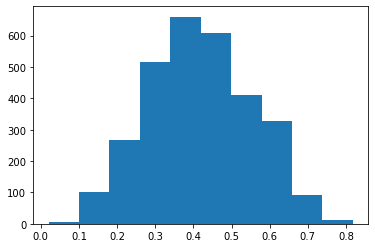

In [43]:
l = len(prob_new)
phi_val = np.zeros(l)
for i in range(l):
    phi_val[i] = phi_calc(prob_new[i],p)
plt.hist(phi_val)
plt.savefig('phi_div3')

In [44]:
l = len(prob_new)
risk_rob = np.zeros(l)
risk_nonrob = np.zeros(l)
for i in range(l):
    risk_rob[i] = riskcalc(rc_res[0],h_eva,R,prob_new[i],par)
    risk_nonrob[i] = riskcalc(non_robust_res[0],h_eva,R,prob_new[i],par)

Text(0.5, 1.0, 'risk portfolio')

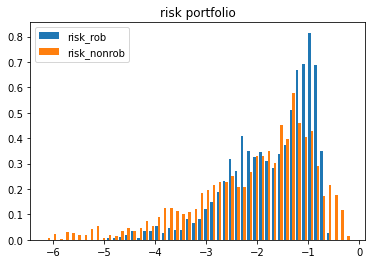

In [45]:
data1 = {'risk_rob':risk_rob, 'risk_nonrob': risk_nonrob}
dt1 = pd.DataFrame(data = data1)
plt.hist(dt1,density = True, bins = 50)
plt.legend(dt1.columns)
plt.title('risk portfolio')
#plt.savefig('robustriskportfolio')

In [48]:
print(np.mean(risk_rob))
print(np.mean(risk_nonrob))
print(np.max(risk_rob))
print(np.max(risk_nonrob))
print(np.min(risk_rob))
print(np.min(risk_nonrob))


-1.7318703286752564
-2.0546778252738145
-0.6247497022200722
-0.175571486290795
-4.914242519083368
-6.165220470020326


In [49]:
N

12

In [106]:
risk_level = np.array([0.01,0.05,0.1,0.5,1,5,10,20])
L = len(risk_level)
upper = np.zeros(L)
lower = np.zeros(L)
w_rob = []
w_nonrob = []
for i in range(L):
    print(i)
    [slope, const] = makepoints(sing_pw,x_points,par)
    affine_res = affine_counterpart_wcret(p,R,r,par,r_f,risk_level[i],phi_conj,slope,const,utility)
    upper[i] = affine_res[1]
    w_rob.append(affine_res[0])
    rank = np.argsort(R.dot(affine_res[0]))
    sets = ranktoset(rank)
    rc_res = robust_counterpart_wcret(sets,p,R,r,par,r_f,risk_level[i],phi_conj, h_conj,utility)
    lower[i] = rc_res[1]
    nonrob_results = non_robust_cut(R,risk_level[i],p,par,r_f, h_eva,h_func, utility, utility_eva)
    w_nonrob.append(nonrob_results[0])

0
1
2
3
4
5
6
7


In [107]:
final_results = {'Risk Level': risk_level,'Upper bound': np.round(upper,decimals = 6), 'Lower bound': np.round(lower, decimals = 6)}
final_results = pd.DataFrame(data=final_results)
final_results

,Risk Level,Upper bound,Lower bound
0,0.01,0.07,0.07
1,0.05,0.07,0.07
2,0.10,0.07,0.07
3,0.50,0.07,0.07
4,1.00,0.07,0.07
5,5.00,0.07,0.07
6,10.00,0.07,0.07
7,20.00,0.07,0.07


In [56]:
final_results.to_latex(index= False)

'\\begin{tabular}{rrr}\n\\toprule\n Risk Level &  Upper bound &  Lower bound \\\\\n\\midrule\n       0.01 &     0.094737 &     0.094665 \\\\\n       0.05 &     0.107105 &     0.107005 \\\\\n       0.10 &     0.122565 &     0.122425 \\\\\n       0.50 &     0.246250 &     0.245782 \\\\\n       1.00 &     0.400860 &     0.399977 \\\\\n       5.00 &     1.637748 &     1.633535 \\\\\n      10.00 &     3.183838 &     3.175482 \\\\\n      20.00 &     6.247100 &     6.232286 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [51]:
[slope, const] = makepoints(sing_pw,x_points,par)
affine_res = affine_counterpart(p,R,r,par,r_f,c,phi_conj,slope,const,utility)
print(affine_res)

(array([-0.05093181,  0.06743504,  0.00320688,  0.02559884, -0.02117181,
       -0.01178822]), 0.10710456669085627)


In [227]:
w = affine_res[0]
rank = np.argsort(R.dot(w))
sets = ranktoset(rank)
robust_counterpart(sets,p,R,r,par,r_f,c,phi_conj, h_conj,utility)

(array([-0.05074932,  0.06110906,  0.00954245,  0.02527009, -0.02165606,
        -0.01181527]),
 0.10678851885385163)

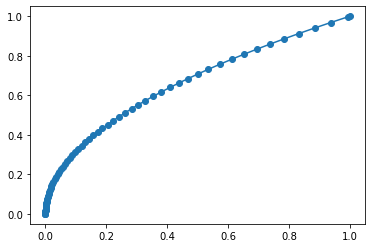

In [218]:
y_points=pw(np.array(x_points),par)
plt.plot(x_points, y_points, "-o")

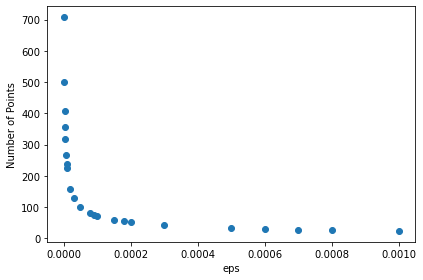

In [18]:
eps_set = np.array([1e-6, 2e-6, 3e-6,4e-6, 5e-6,7e-6,9e-6,0.00001,0.00002, 0.00003, 0.00005,0.00008,0.00009,0.0001,0.00015,0.00018, 0.0002,0.0003, 0.0005,0.0006,0.0007, 0.0008, 0.001])
K = []
par = 0.5
for eps in eps_set:
    x_points = affine_approx(eps,argmax_pw,max_error_pw,par)
    K.append(len(x_points))
K = np.array(K)
LogK = np.log(np.array(K))
plt.xlabel('eps')
plt.ylabel('Number of Points')
plt.plot(np.array(eps_set),K,'o')
plt.tight_layout()
plt.savefig('Kfigure.eps', format = 'eps')    

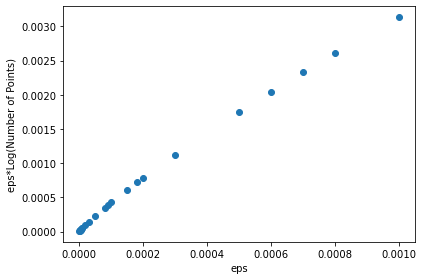

In [19]:
y = LogK*eps_set
plt.plot(np.array(eps_set),y,'o')
plt.xlabel('eps')
plt.ylabel('eps*Log(Number of Points)')
plt.tight_layout()
plt.savefig('LogKfigure', format = 'eps')

In [56]:
K

array([708, 501, 409, 355, 317, 268, 237, 225, 159, 130, 101,  80,  76,
        72,  59,  54,  51,  42,  33,  30,  28,  26,  23])

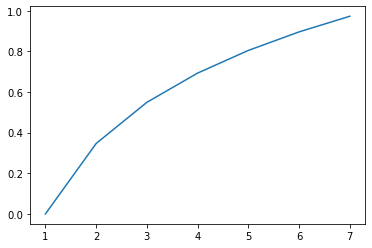

In [22]:
x = np.array([1,2,3,4,5,6,7])
y = np.sqrt(x)
z = np.log(y)
plt.plot(x,z)

In [14]:
def steun_cut(R,r,p,par,r_f,c,h_func, phi_func,utility, utility_eva, h_eval,eps,argmaxfunc,max_error):
    x_points = affine_approx(eps,argmaxfunc, max_error,par)
    j_max = 0
    for i in range(50):
        max_vio = -np.inf
        [slope, const] = makepoints(h_eval,x_points,par)
        [w_aff, aff_value] = affine_counterpart(p,R,r,par,r_f,c,phi_conj,slope,const,utility)
        rank = np.argsort(R.dot(w_aff))
        print('aff_value',aff_value)
        [q,rbvalue] = robustcheck_q(w_aff,R,r,p,par,r_f,h_func, phi_func,utility, utility_eva)
        print('rbvalue',rbvalue)
        if rbvalue <= c:
            return('hoera robust')
        N = len(q)
        for j in range(N):
            new_point = np.sum(q[rank[0:j+1]])
            violation = h_eval(new_point,par) - piece_affine_eval(x_points, new_point, h_eval, par)
            if violation > max_vio:
                max_vio = violation
                j_max = j+1
        if np.sum(q[rank[0:j_max+1]]) not in x_points:
            print('added', j_max,'max_vio', max_vio)
            x_points = np.append(x_points,np.sum(q[rank[0:j_max+1]]))
            x_points = np.sort(x_points)
    return(w_aff)
    

In [15]:
h_eval = sing_pw
max_error = max_error_singpw
argmaxfunc = argmax_sing_power

In [16]:
steun_cut(R,r,p,par,r_f,c,h_func, phi_func,utility, utility_eva, h_eval,eps,argmaxfunc,max_error)

aff_value 0.11572451911403811
rbvalue 0.07946790904719452
added 18 max_vio 0.09999480927687171
aff_value 0.10995660934779253
rbvalue 0.05968502355681825
added 221 max_vio 0.03377378685468446
aff_value 0.1089212583133734
rbvalue 0.056336654225886316
added 3 max_vio 0.026010397654209982
aff_value 0.10810101524565799
rbvalue 0.05357815867162111
added 54 max_vio 0.023929811996932226
aff_value 0.10775280514730243
rbvalue 0.05244557330635479
added 163 max_vio 0.008546124412125877
aff_value 0.10766632590176654
rbvalue 0.05216663532397403
added 1 max_vio 0.008450541966656788
aff_value 0.1075460549281795
rbvalue 0.05176290342326137
added 286 max_vio 0.008341197356723784
aff_value 0.1073285444967261
rbvalue 0.051055503305631564
added 33 max_vio 0.006169670215952161
aff_value 0.10728131065131163
rbvalue 0.050898353004072444
added 81 max_vio 0.00579550187054978
aff_value 0.10723949491683168
rbvalue 0.05076355243231824
added 9 max_vio 0.004515127321653822
aff_value 0.10719519459757115
rbvalue 0.050

array([-0.05097822,  0.06751146,  0.00316899,  0.02557942, -0.02095593,
       -0.01189493])

In [73]:
r

0.6590162040654062

In [313]:
N_size = 100
R_sam = np.zeros((N_size,3))
R_states = np.array([[2,2**3/5-1,-1],[2,2**3/5-1,-3],[0,-1,-1],[0,-1,1],[-2,-2**3/5-1,1],[-2,-2**3/5-1,3]])
m = len(R_states)
p_est = np.zeros(m)
for i in range(N_size):
    R1 = np.sum(np.random.binomial(1,0.5,size = 2)*2-1)
    R2 = R1**3/5-1
    R3 = -R1 + np.random.binomial(1,0.5)*2-1
    R_sam[i] = np.array([R1,R2,R3])
    for j in range(6):
        if np.array_equal(R_sam[i],R_states[j]):
            p_est[j] = p_est[j] + 1
            break
p_est = p_est/np.sum(p_est)

In [314]:
rho = phi_dot/(2*N_size)*scipy.stats.chi2.ppf(0.95,m)

In [315]:
[slope, const] = makepoints(sing_pw,x_points,par)
affine_res = affine_counterpart_riskmin(p_est,R_states,rho,par,phi_conj,slope,const,utility)
print(affine_res)
w = affine_res[0]
rank = np.argsort(R_states.dot(w))
sets = ranktoset(rank)
rc_res = robust_counterpart_riskmin(sets,p_est,R_states,rho,par,phi_conj, h_conj,utility)
print(rc_res)
non_robust_res = non_robust_cut_riskmin(R_states,p_est,par,h_eva,h_func, utility, utility_eva)
print(non_robust_res)

(array([ 9.50914846, -9.99999998,  1.49085152]), 8.964307817791207)
(array([ 9.50904486, -9.99999997,  1.49095511]), 8.964031539299553)
0.6427999999847307 [-25.8428] 25.842799999090754
-9.39405050797324 [-10.11883151] 10.118831508087505
-9.264069786368246 [-9.55119084] 9.551190844353934
-9.474700000006365 [-9.4747] 9.474699999949733
(array([  9.5, -10. ,   1.5]), 9.474699999949733, 3)


In [31]:
r

0.562838197664435

In [216]:
A = np.array([1,0.5,3])
np.min(A)

0.5